In [99]:
import pandas as pd
import numpy as np

In [100]:
df=pd.read_csv("../data/raw/used_car.csv")

In [101]:
df.head(10).T

,0,1,2,3,4,5,6,7,8,9
Unnamed: 0,0,1,2,3,4,5,6,7,8,9
symboling,3,3,1,2,2,2,1,1,1,0
normalized-losses,NaN,NaN,NaN,164.0,164.0,NaN,158.0,NaN,158.0,NaN
make,alfa-romero,alfa-romero,alfa-romero,audi,audi,audi,audi,audi,audi,audi
fuel-type,gas,gas,gas,gas,gas,gas,gas,gas,gas,gas
aspiration,std,std,std,std,std,std,std,std,turbo,turbo
num-of-doors,two,two,two,four,four,two,four,four,four,two
body-style,convertible,convertible,hatchback,sedan,sedan,sedan,sedan,wagon,sedan,hatchback
drive-wheels,rwd,rwd,rwd,fwd,4wd,fwd,fwd,fwd,fwd,4wd
engine-location,front,front,front,front,front,front,front,front,front,front


In [102]:
df.columns

Index(['Unnamed: 0', 'symboling', 'normalized-losses', 'make', 'fuel-type',
       'aspiration', 'num-of-doors', 'body-style', 'drive-wheels',
       'engine-location', 'wheel-base', 'length', 'width', 'height',
       'curb-weight', 'engine-type', 'num-of-cylinders', 'engine-size',
       'fuel-system', 'bore', 'stroke', 'compression-ratio', 'horsepower',
       'peak-rpm', 'city-mpg', 'highway-mpg', 'price'],
      dtype='object')

In [103]:
drop_columns=['Unnamed: 0','engine-location', 'stroke','compression-ratio']
df.drop(columns=drop_columns,inplace=True)
df.head().T

,0,1,2,3,4
symboling,3,3,1,2,2
normalized-losses,NaN,NaN,NaN,164.0,164.0
make,alfa-romero,alfa-romero,alfa-romero,audi,audi
fuel-type,gas,gas,gas,gas,gas
aspiration,std,std,std,std,std
num-of-doors,two,two,two,four,four
body-style,convertible,convertible,hatchback,sedan,sedan
drive-wheels,rwd,rwd,rwd,fwd,4wd
wheel-base,88.6,88.6,94.5,99.8,99.4
length,168.8,168.8,171.2,176.6,176.6


In [104]:
df.replace('?',np.nan,inplace=True)

In [105]:
df.isnull().sum()

symboling             0
normalized-losses    41
make                  0
fuel-type             0
aspiration            0
num-of-doors          2
body-style            0
drive-wheels          0
wheel-base            0
length                0
width                 0
height                0
curb-weight           0
engine-type           0
num-of-cylinders      0
engine-size           0
fuel-system           0
bore                  4
horsepower            2
peak-rpm              2
city-mpg              0
highway-mpg           0
price                 4
dtype: int64

In [106]:
df.dropna(subset=['price'],inplace=True)
df['price'].isna().sum()

0

In [107]:
df.shape

(201, 23)

In [108]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 201 entries, 0 to 204
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          201 non-null    int64  
 1   normalized-losses  164 non-null    float64
 2   make               201 non-null    object 
 3   fuel-type          201 non-null    object 
 4   aspiration         201 non-null    object 
 5   num-of-doors       199 non-null    object 
 6   body-style         201 non-null    object 
 7   drive-wheels       201 non-null    object 
 8   wheel-base         201 non-null    float64
 9   length             201 non-null    float64
 10  width              201 non-null    float64
 11  height             201 non-null    float64
 12  curb-weight        201 non-null    int64  
 13  engine-type        201 non-null    object 
 14  num-of-cylinders   201 non-null    object 
 15  engine-size        201 non-null    int64  
 16  fuel-system        201 non-null

In [109]:
num_missing_values=["normalized-losses","bore","horsepower","peak-rpm"]
for value in num_missing_values:
    median_value=df[value].median()
    df[value]=df[value].replace(np.nan,median_value)

# cat_impute_value
df['num-of-doors']=df['num-of-doors'].fillna(df['num-of-doors'].mode()[0])
df.isnull().sum()

symboling            0
normalized-losses    0
make                 0
fuel-type            0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                0
dtype: int64

In [110]:
df.head().T

,0,1,2,3,4
symboling,3,3,1,2,2
normalized-losses,115.0,115.0,115.0,164.0,164.0
make,alfa-romero,alfa-romero,alfa-romero,audi,audi
fuel-type,gas,gas,gas,gas,gas
aspiration,std,std,std,std,std
num-of-doors,two,two,two,four,four
body-style,convertible,convertible,hatchback,sedan,sedan
drive-wheels,rwd,rwd,rwd,fwd,4wd
wheel-base,88.6,88.6,94.5,99.8,99.4
length,168.8,168.8,171.2,176.6,176.6


In [111]:
df.drop_duplicates(inplace=True)
df.reset_index(drop=True,inplace=True)

In [112]:
linear_df=df.drop(columns=['normalized-losses','peak-rpm','height','highway-mpg','symboling'],axis=0)
linear_df.head().T

,0,1,2,3,4
make,alfa-romero,alfa-romero,alfa-romero,audi,audi
fuel-type,gas,gas,gas,gas,gas
aspiration,std,std,std,std,std
num-of-doors,two,two,two,four,four
body-style,convertible,convertible,hatchback,sedan,sedan
drive-wheels,rwd,rwd,rwd,fwd,4wd
wheel-base,88.6,88.6,94.5,99.8,99.4
length,168.8,168.8,171.2,176.6,176.6
width,64.1,64.1,65.5,66.2,66.4
curb-weight,2548,2548,2823,2337,2824


In [113]:
df.head().T

,0,1,2,3,4
symboling,3,3,1,2,2
normalized-losses,115.0,115.0,115.0,164.0,164.0
make,alfa-romero,alfa-romero,alfa-romero,audi,audi
fuel-type,gas,gas,gas,gas,gas
aspiration,std,std,std,std,std
num-of-doors,two,two,two,four,four
body-style,convertible,convertible,hatchback,sedan,sedan
drive-wheels,rwd,rwd,rwd,fwd,4wd
wheel-base,88.6,88.6,94.5,99.8,99.4
length,168.8,168.8,171.2,176.6,176.6


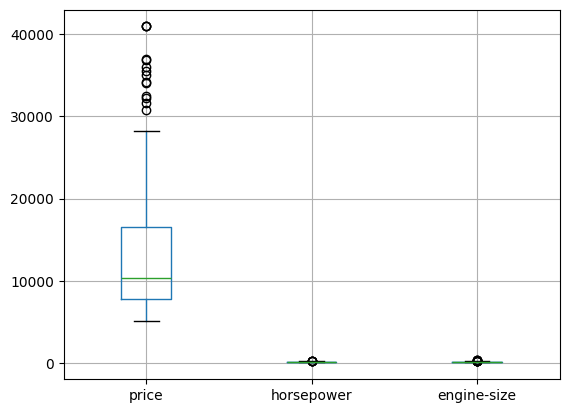

In [114]:
# Outlier handling for linear   -->  less critical for trees since it splits on thresholds
capp_cols=['price','horsepower','engine-size','curb-weight']

for col in capp_cols:
    upper=linear_df[col].quantile(0.99)
    linear_df[col]=linear_df[col].clip(upper=upper)

# verify
import matplotlib.pyplot as plt
linear_df[['price','horsepower','engine-size']].boxplot()
plt.show()

In [115]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

dropdown_values = {
    "make": sorted(df["make"].unique().tolist()),
    "fuel-type": sorted(df["fuel-type"].unique().tolist()),
    "aspiration": sorted(df["aspiration"].unique().tolist()),
    "num-of-doors": sorted(df["num-of-doors"].unique().tolist()),
    "body-style": sorted(df["body-style"].unique().tolist()),
    "drive-wheels": sorted(df["drive-wheels"].unique().tolist()),
    "engine-type": sorted(df["engine-type"].unique().tolist()),
    "num-of-cylinders": sorted(df["num-of-cylinders"].unique().tolist()),
    "fuel-system": sorted(df["fuel-system"].unique().tolist())
}

joblib.dump(dropdown_values, "../models/dropdown_values.pkl")

print("Dropdown values saved.")

Dropdown values saved.


In [116]:
# Ordinal mapping -->  feature has natural order
cyl_map={'two':2,'three':3,'four':4,'five':5,'six':6,'eight':8,'twelve':12}

df['num-of-cylinders']=df['num-of-cylinders'].map(cyl_map)

#  Binary Encoding      -->    feature has 2 categories
df['fuel-type']=(df['fuel-type']=='diesel').astype(int)
df['aspiration']=(df['aspiration']=='turbo').astype(int)
df['num-of-doors']=(df['num-of-doors']=='two').astype(int)

#  One hot Encoding   -->  feature has multiple categories (2-8)
ohe_cols=['body-style','drive-wheels','engine-type','fuel-system']
df=pd.get_dummies(df,columns=ohe_cols,drop_first=True)

print(df.shape)   # cols increases

(201, 37)


In [117]:
#  Linear DF

# Ordinal mapping -->  feature has natural order
cyl_map1={'two':2,'three':3,'four':4,'five':5,'six':6,'eight':8,'twelve':12}

linear_df['num-of-cylinders']=linear_df['num-of-cylinders'].map(cyl_map1)

#  Binary Encoding      -->    feature has 2 categories
linear_df['fuel-type']=(linear_df['fuel-type']=='diesel').astype(int)
linear_df['aspiration']=(linear_df['aspiration']=='turbo').astype(int)
linear_df['num-of-doors']=(linear_df['num-of-doors']=='two').astype(int)

#  One hot Encoding   -->  feature has multiple categories (2-8)
ohe_cols=['body-style','drive-wheels','engine-type','fuel-system']
linear_df=pd.get_dummies(linear_df,columns=ohe_cols,drop_first=True)

In [118]:
from sklearn.model_selection import train_test_split

X=df.drop(columns=['price'])
y=df['price']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

print("Train:", X_train.shape, "| Test:", X_test.shape)

# Target encode 'make' — fit on TRAIN ONLY
make_means = X_train.join(y_train)['make'].map(
    y_train.groupby(X_train['make']).mean()
)
make_map = y_train.groupby(X_train['make']).mean()
X_train['make'] = X_train['make'].map(make_map)
X_test['make']  = X_test['make'].map(make_map)
X_test['make']=X_test['make'].fillna(make_map.mean())  # unseen brands

Train: (160, 36) | Test: (41, 36)


In [119]:
linear_X=linear_df.drop(columns=['price'])
linear_y=linear_df['price']

linear_X_train,linear_X_test,linear_y_train,linear_y_test=train_test_split(linear_X,linear_y,test_size=0.2,random_state=42)

print("Train:", linear_X_train.shape, "| Test:", linear_X_test.shape)

# Target encode 'make' — fit on TRAIN ONLY
make_means = linear_X_train.join(linear_y_train)['make'].map(
    linear_y_train.groupby(linear_X_train['make']).mean()
)
make_map = linear_y_train.groupby(linear_X_train['make']).mean()
linear_X_train['make'] = linear_X_train['make'].map(make_map)
linear_X_test['make']  = linear_X_test['make'].map(make_map)
linear_X_test['make']=linear_X_test['make'].fillna(make_map.mean())  # unseen brands

Train: (160, 31) | Test: (41, 31)


In [120]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

linear_X_train_scaled=scaler.fit_transform(linear_X_train)
linear_X_test_scaled=scaler.transform(linear_X_test)



In [121]:

# Apply log transform to target 
linear_y_train_log = np.log1p(linear_y_train) 
linear_y_test_log = np.log1p(linear_y_test) 

# After model.predict(), reverse it like this: # y_pred_actual = np.expm1(model.predict(X_test_scaled)) 
# Compute RMSE on original price scale (not log scale) 
# from sklearn.metrics import mean_squared_error 
# y_pred_log = model.predict(X_test_scaled) y_pred_actual = np.expm1(y_pred_log) rmse = np.sqrt(mean_squared_error(y_test, y_pred_actual)) print(f"RMSE: ${rmse:,.0f}")

In [122]:
print(X_train.shape)
print(X_test.shape)

print(X_train.isnull().sum().sum())
print(X_test.isnull().sum().sum())

print(y_train.isnull().sum())
print(y_test.isnull().sum())

print(X_train.duplicated().sum())
print(X_test.duplicated().sum())

print("------------------------------------------------------")

print(linear_X_train.shape)
print(linear_X_test.shape)

print(linear_X_train.isnull().sum().sum())
print(linear_X_test.isnull().sum().sum())

print(linear_y_train.isnull().sum())
print(linear_y_test.isnull().sum())

print(linear_X_train.duplicated().sum())
print(linear_X_test.duplicated().sum())

(160, 36)
(41, 36)
0
0
0
0
5
0
------------------------------------------------------
(160, 31)
(41, 31)
0
0
0
0
5
0


In [123]:
# Combine features and target
train_df = X_train.copy()
train_df['price'] = y_train.values

test_df = X_test.copy()
test_df['price'] = y_test.values

# Save as CSV
train_df.to_csv('../data/processed/train.csv', index=False)
test_df.to_csv('../data/processed/test.csv', index=False)

In [124]:
# Combine features and target
linear_train_df = linear_X_train.copy()
linear_train_df['price'] = linear_y_train.values

linear_test_df = linear_X_test.copy()
linear_test_df['price'] = linear_y_test.values

# Save as CSV
linear_train_df.to_csv('../data/processed/linear_train.csv', index=False)
linear_test_df.to_csv('../data/processed/linear_test.csv', index=False)

In [125]:


os.makedirs("models", exist_ok=True)

joblib.dump(make_map, "../models/make_encoder.pkl")
joblib.dump(scaler, "../models/scaler.pkl")      # if tree model doesn't use it, you can skip
joblib.dump(X_train.columns.tolist(), "../models/features.pkl")

['../models/features.pkl']